**LAB EXPERIMENT - 5**\
**Classification using K-Nearest Neighbors (KNN) and
Decision Tree**

Name : Poovika M\
Roll No : 24BAD087

**SCENARIO 1**

**CODE INTERPRETATION**

 1. Import Libraries

    => Libraries are imported for:

    => Data handling (pandas, numpy)

    => Visualization (matplotlib, seaborn)

    => Model building & evaluation (sklearn)

 2. Load Dataset

    The breast cancer dataset is loaded and inspected using:

    => head()

    => info()

    => isnull()

    This checks structure and missing values.

 3. Select Features & Target

    Selected input features:

    => radius_mean

    => texture_mean

    => perimeter_mean

    => area_mean

    => smoothness_mean

    Target variable:

    => diagnosis (Benign / Malignant)

 4. Encode Target Labels

    Diagnosis is converted into numeric format:

    Benign = 0

    Malignant = 1

 5. Feature Scaling

    StandardScaler is applied to standardize feature values (important for KNN).

 6. Train-Test Split

    Dataset is divided into:

    => 80% training data

    => 20% testing data

 7. Train KNN Model (K = 5)

    A K-Nearest Neighbors classifier is trained with K = 5.

 8. Prediction & Evaluation

    Model predicts diagnosis for test data.

    Performance is measured using:\
    => Accuracy

    => Classification Report

    => Confusion Matrix

    => Misclassified cases are identified.

 9. Accuracy vs K Analysis

    Model is tested for K values from 1 to 20.
    A graph is plotted to find the best K value.

 10. Confusion Matrix Visualization

      Heatmap is plotted to visualize correct and incorrect classifications.

 11. Decision Boundary Visualization

      Using two features (radius & texture), a 2D decision boundary is plotted to show classification regions.

 12. Conclusion

      The program applies KNN classification to detect breast cancer (Benign/Malignant), evaluates performance, and analyzes the effect of different K values.

POOVIKA M - 24BAD087
First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  textu

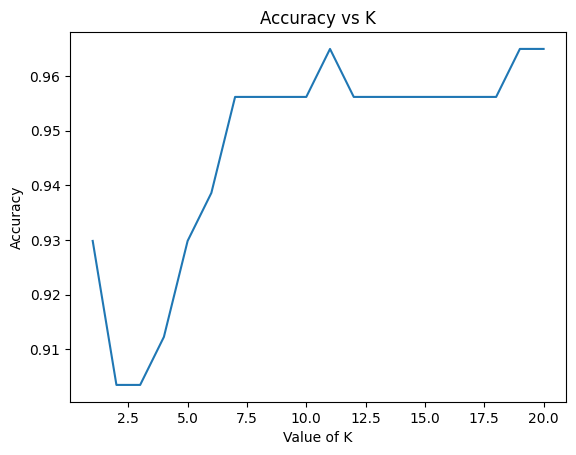

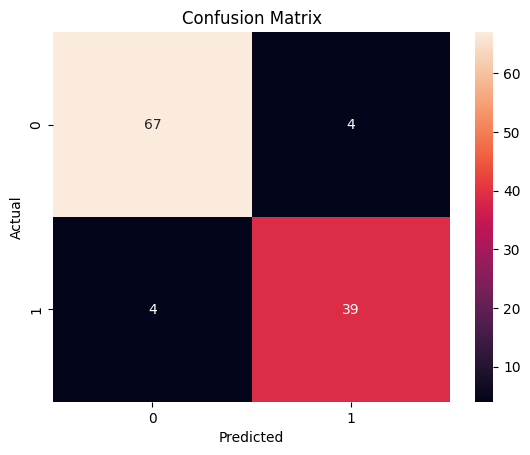

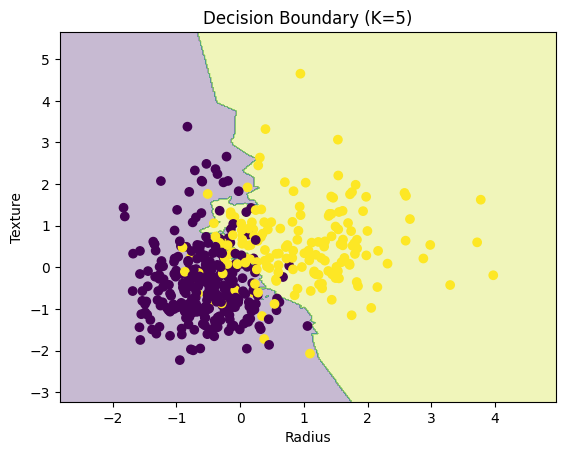

In [1]:
#POOVIKA M - 24BAD087
#EXP_5 : SCENARIO 1

print("POOVIKA M - 24BAD087")

#Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Load Dataset
df = pd.read_csv("/content/sample_data/breast-cancer.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

#Select Required Features
features = ['radius_mean', 'texture_mean',
            'perimeter_mean', 'area_mean',
            'smoothness_mean']

X = df[features]
y = df['diagnosis']

#Encode Target Labels
le = LabelEncoder()
y = le.fit_transform(y)   # Benign=0, Malignant=1

#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

#Train KNN Classifier (K=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

#Predict Diagnosis Labels
y_pred = knn.predict(X_test)

#Evaluate Performance
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

#Identify Misclassified Cases
misclassified = np.where(y_test != y_pred)
print("\nMisclassified Indices:", misclassified)
print("Number of Misclassified Cases:", len(misclassified[0]))

#Experiment with Different K Values
accuracy_list = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    accuracy_list.append(accuracy_score(y_test, y_pred_k))

# Plot Accuracy vs K
plt.figure()
plt.plot(range(1, 21), accuracy_list)
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

#Confusion Matrix Visualization
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Decision Boundary (Using 2 Features)
X2 = df[['radius_mean', 'texture_mean']]
X2_scaled = scaler.fit_transform(X2)

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_scaled, y, test_size=0.2, random_state=42)

model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_train2, y_train2)

#Create mesh grid
h = 0.02
x_min, x_max = X_train2[:, 0].min() - 1, X_train2[:, 0].max() + 1
y_min, y_max = X_train2[:, 1].min() - 1, X_train2[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train2[:, 0], X_train2[:, 1], c=y_train2)
plt.xlabel("Radius")
plt.ylabel("Texture")
plt.title("Decision Boundary (K=5)")
plt.show()


**SCENARIO 2**

**CODE INTERPRETATION**

 1. Import Libraries

    => Libraries are imported for:

    => Data handling (pandas, numpy)

    => Visualization (matplotlib, seaborn)

    => Decision Tree model & evaluation (sklearn)

 2. Load Dataset

    Loan dataset is loaded and checked using:

    => head()

    => info()

    => isnull()

    This verifies structure and missing values.

 3. Handle Missing Values

    Numerical columns filled with median

    Categorical columns filled with mode

 4. Select Features & Target

    Selected features:

    => ApplicantIncome

    => LoanAmount

    => Credit_History

    => Education

    => Property_Area

    Target variable:

    => Loan_Status (Approved / Rejected)

 5. Encode Categorical Data

    Education & Property_Area converted to numeric

    Loan_Status encoded (Approved = 1, Rejected = 0)

 6. Train-Test Split

    Dataset split into:

    => 80% training

    => 20% testing

 7. Train Decision Tree Model

    Decision Tree classifier is trained using training data.

 8. Experiment with Tree Depth

    Tree depth from 1 to 10 is tested.
    Training & testing accuracy are recorded to check performance.

 9. Prediction & Evaluation

    Model predicts loan approval.
    Performance measured using:\
    => Accuracy

    => Classification Report

    => Confusion Matrix

 10. Feature Importance

      Model identifies most important features affecting loan approval.

 11. Overfitting Check

      Training accuracy is compared with testing accuracy.
      If training accuracy is much higher → Overfitting.

 12. Compare Shallow vs Deep Tree

      Shallow tree (max_depth=3)

      Deep tree (no depth limit)
      
      Accuracy comparison is done.

 13. Visualization

      => Confusion matrix heatmap

      => Decision tree structure plot

      => Feature importance bar chart

 14. Conclusion

      The program builds a Decision Tree model to predict loan approval, evaluates performance, analyzes feature importance, and checks overfitting.

POOVIKA M - 24BAD087
First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural

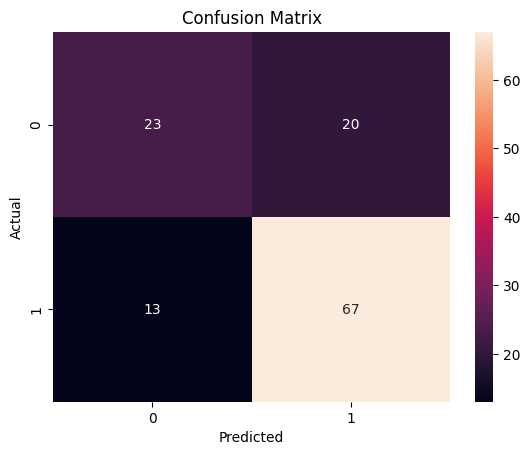

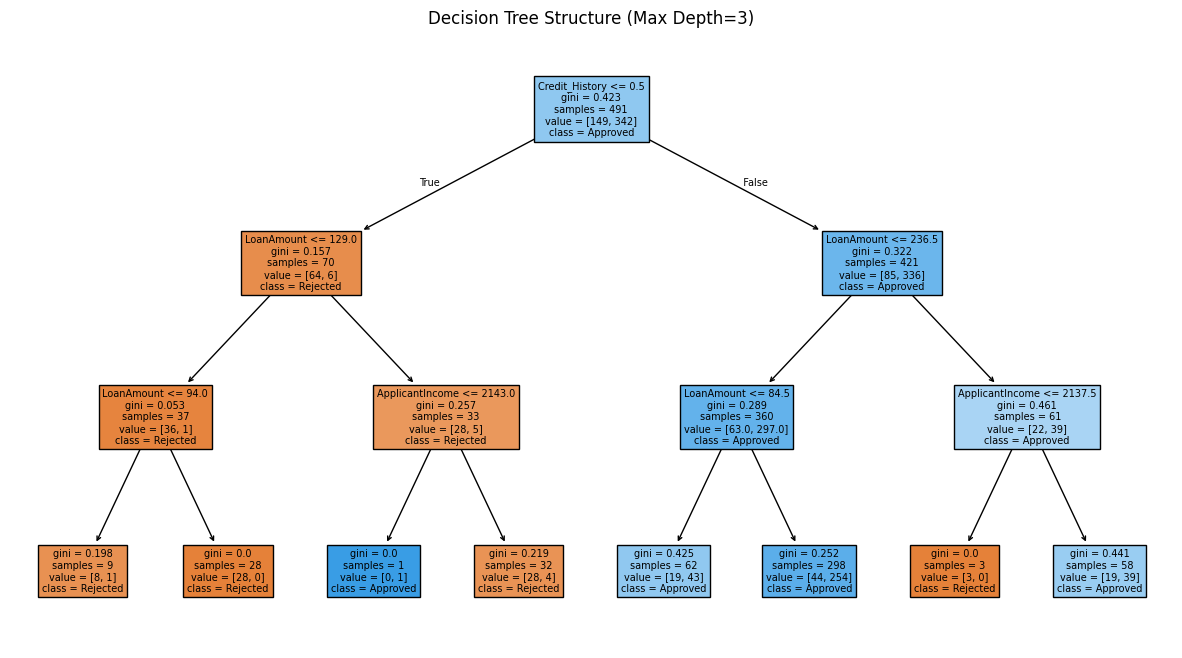

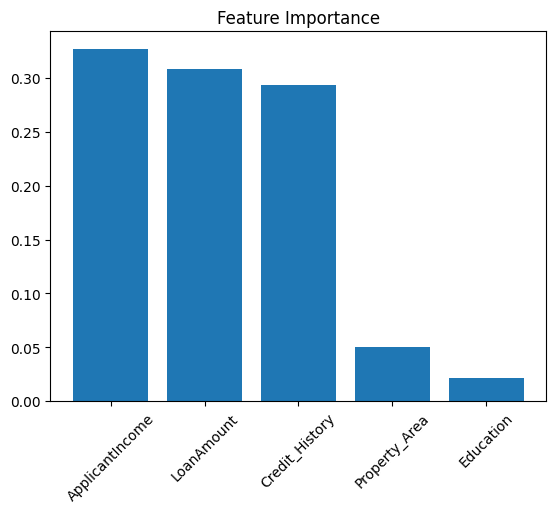

In [2]:
#POOVIKA M - 24BAD087
#EXP_5 : SCENARIO 2

print("POOVIKA M - 24BAD087")

#Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Load Dataset
df = pd.read_csv("/content/sample_data/train_u6lujuX_CVtuZ9i (1).csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

#Preprocessing

#Handle Missing Values
#Fill numerical columns with median
df['ApplicantIncome'].fillna(df['ApplicantIncome'].median())
df['LoanAmount'].fillna(df['LoanAmount'].median())

#Fill categorical columns with mode
df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['Education'].fillna(df['Education'].mode()[0])
df['Property_Area'].fillna(df['Property_Area'].mode()[0])
df['Loan_Status'].fillna(df['Loan_Status'].mode()[0])

#Select Required Features
features = ['ApplicantIncome', 'LoanAmount',
            'Credit_History', 'Education', 'Property_Area']

X = df.loc[:, features].copy()
y = df['Loan_Status']

#Encode Categorical Variables
le = LabelEncoder()

for col in ['Education', 'Property_Area']:
    X.loc[:, col] = le.fit_transform(X[col])

y = le.fit_transform(y)  # Approved=1, Rejected=0

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Train Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

#Experiment with Tree Depth
train_acc = []
test_acc = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

#Predict Loan Status
y_pred = dt.predict(X_test)

#Evaluate Performance
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

#Feature Importance
importance = dt.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_df)

#Detect Overfitting
print("\nTraining Accuracy:", dt.score(X_train, y_train))
print("Testing Accuracy:", dt.score(X_test, y_test))

# If training accuracy >> testing accuracy → Overfitting

#Compare Shallow vs Deep Trees
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
deep_tree = DecisionTreeClassifier(max_depth=None, random_state=42)

shallow_tree.fit(X_train, y_train)
deep_tree.fit(X_train, y_train)

print("\nShallow Tree Accuracy:", shallow_tree.score(X_test, y_test))
print("Deep Tree Accuracy:", deep_tree.score(X_test, y_test))

#Visualization
#Confusion Matrix Heatmap
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Tree Structure Plot (Shallow Tree)
plt.figure(figsize=(15,8))
plot_tree(shallow_tree,
          feature_names=features,
          class_names=["Rejected", "Approved"],
          filled=True)
plt.title("Decision Tree Structure (Max Depth=3)")
plt.show()

#Feature Importance Plot
plt.figure()
plt.bar(feature_importance_df['Feature'],
        feature_importance_df['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()


